# Vectorcardiogram (VCG) from 12‑lead ECG

This notebook reads a WFDB record and computes an approximate 3D VCG (X/Y/Z) using a standard linear transform (Frank leads approximation) based on leads **I, II, V1–V6**.

Plots use Plotly (interactive pan/zoom and 3D rotation).

Adjust `RECORD_PATH` to any WFDB record (path without extension).

In [24]:
from pathlib import Path

import numpy as np
import wfdb
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Plotly rendering: some environments don't ship nbformat, which breaks fig.show() inline.
# Fallback: open in a browser tab, or write HTML to disk.
try:
    import nbformat as _nbformat  # noqa: F401
except Exception:
    pio.renderers.default = "browser"
else:
    pio.renderers.default = "notebook_connected"

print("Plotly renderer:", pio.renderers.default)

def show_or_save(fig, name: str, out_dir: str = "vcg_outputs"):
    """Show plotly figure, or save to HTML if inline rendering isn't available."""
    try:
        fig.show()
    except Exception as e:
        out = Path(out_dir)
        out.mkdir(parents=True, exist_ok=True)
        path = out / f"{name}.html"
        fig.write_html(path, include_plotlyjs="cdn")
        print(f"Could not render inline ({e}). Wrote: {path}")

# From src/ecg_chagas_embeddings/notebooks/neurokit.ipynb (known-good example)
RECORD_PATH = "/home/flo178/projects/master-thesis/datasets/physionet2025/ptb-xl/records500/00000/00069_hr"
RECORD_PATH = "/home/flo178/projects/master-thesis/datasets/physionet2025/sami-trop/processed/23710"

signals, info = wfdb.rdsamp(RECORD_PATH)
fs = float(info.get("fs", np.nan))
lead_names = list(info.get("sig_name", []))

print("signals shape:", signals.shape)  # (n_samples, n_leads)
print("fs:", fs)
print("leads:", lead_names)


Plotly renderer: notebook_connected
signals shape: (2934, 12)
fs: 400.0
leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [25]:
def _norm_lead(name: str) -> str:
    return name.strip().upper().replace(" ", "")


def compute_vcg_frank_approx(signals: np.ndarray, lead_names: list[str]) -> np.ndarray:
    """Compute VCG (X,Y,Z) via a simple linear transform.

    Uses coefficients as commonly shown in the Wikipedia VCG transform example,
    combining I, II, and V1–V6.

    Returns:
        vcg: ndarray shape (n_samples, 3) with columns [X, Y, Z]
    """
    if signals.ndim != 2:
        raise ValueError(f"Expected signals with shape (n_samples, n_leads), got {signals.shape}")

    name_to_idx = {_norm_lead(n): i for i, n in enumerate(lead_names)}

    def L(name: str) -> np.ndarray:
        key = _norm_lead(name)
        if key not in name_to_idx:
            raise KeyError(f"Missing required lead '{name}'. Available: {sorted(name_to_idx.keys())}")
        return signals[:, name_to_idx[key]]

    I = L("I")
    II = L("II")
    V1 = L("V1")
    V2 = L("V2")
    V3 = L("V3")
    V4 = L("V4")
    V5 = L("V5")
    V6 = L("V6")

    # Coefficients (see Wikipedia "Vectorcardiography" page screenshot)
    X = -(
        -0.172 * V1
        - 0.074 * V2
        + 0.122 * V3
        + 0.231 * V4
        + 0.239 * V5
        + 0.194 * V6
        + 0.156 * I
        - 0.010 * II
    )

    Y = (
        0.057 * V1
        - 0.019 * V2
        - 0.106 * V3
        - 0.022 * V4
        + 0.041 * V5
        + 0.048 * V6
        - 0.227 * I
        + 0.887 * II
    )

    Z = -(
        -0.229 * V1
        - 0.310 * V2
        - 0.246 * V3
        - 0.063 * V4
        + 0.055 * V5
        + 0.108 * V6
        + 0.022 * I
        + 0.102 * II
    )

    return np.stack([X, Y, Z], axis=1)


vcg = compute_vcg_frank_approx(signals, lead_names)
print("vcg shape:", vcg.shape)


vcg shape: (2934, 3)


Could not render inline (Mime type rendering requires nbformat>=4.2.0 but it is not installed). Wrote: vcg_outputs/vcg_timeseries.html
Could not render inline (Mime type rendering requires nbformat>=4.2.0 but it is not installed). Wrote: vcg_outputs/vcg_loops.html


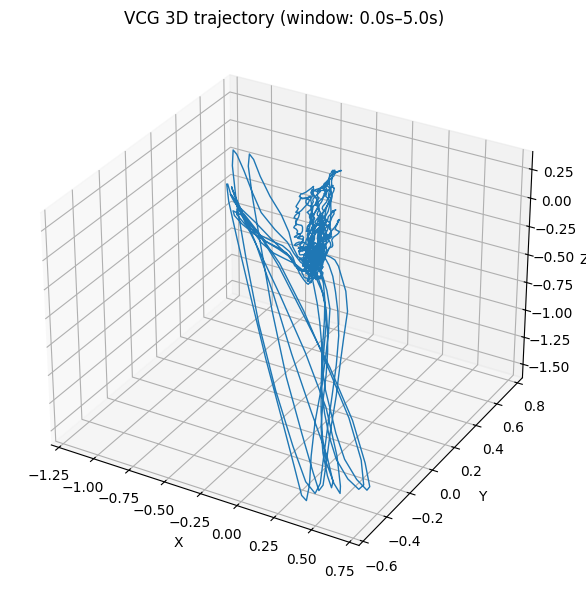

In [26]:
X, Y, Z = vcg[:, 0], vcg[:, 1], vcg[:, 2]

n_samples = len(X)
t = np.arange(n_samples) / fs if np.isfinite(fs) else np.arange(n_samples)

# --- Interactive time-series (with range slider) ---
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.03)
fig.add_trace(go.Scatter(x=t, y=X, name='X', line=dict(width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=t, y=Y, name='Y', line=dict(width=1)), row=2, col=1)
fig.add_trace(go.Scatter(x=t, y=Z, name='Z', line=dict(width=1)), row=3, col=1)

x_title = 'Time (s)' if np.isfinite(fs) else 'Sample'
fig.update_yaxes(title_text='X', row=1, col=1)
fig.update_yaxes(title_text='Y', row=2, col=1)
fig.update_yaxes(title_text='Z', row=3, col=1)
fig.update_xaxes(title_text=x_title, row=3, col=1)

fig.update_layout(
    title='VCG components (interactive) — use the range slider to zoom',
    height=650,
    showlegend=False,
)
fig.update_xaxes(
    rangeslider=dict(visible=True),
    rangeselector=dict(
        buttons=list([
            dict(count=1, label='1s', step='second', stepmode='backward'),
            dict(count=5, label='5s', step='second', stepmode='backward'),
            dict(count=10, label='10s', step='second', stepmode='backward'),
            dict(step='all')
        ])
    ) if np.isfinite(fs) else None,
)
show_or_save(fig, "vcg_timeseries")

# --- Loops & 3D trajectory (interactive) ---
# Choose a window to plot (keep it small for performance)
start_s = 0.0
duration_s = 5.0
start = int(start_s * fs) if np.isfinite(fs) else 0
end = int((start_s + duration_s) * fs) if np.isfinite(fs) else min(2000, n_samples)
start = max(0, min(start, n_samples))
end = max(start + 1, min(end, n_samples))

Xs, Ys, Zs = X[start:end], Y[start:end], Z[start:end]

loop_fig = make_subplots(rows=1, cols=3, subplot_titles=['XY loop', 'XZ loop', 'YZ loop'])
loop_fig.add_trace(go.Scatter(x=Xs, y=Ys, mode='lines', name='XY', line=dict(width=1)), row=1, col=1)
loop_fig.add_trace(go.Scatter(x=Xs, y=Zs, mode='lines', name='XZ', line=dict(width=1)), row=1, col=2)
loop_fig.add_trace(go.Scatter(x=Ys, y=Zs, mode='lines', name='YZ', line=dict(width=1)), row=1, col=3)
loop_fig.update_xaxes(title_text='X', row=1, col=1)
loop_fig.update_yaxes(title_text='Y', row=1, col=1)
loop_fig.update_xaxes(title_text='X', row=1, col=2)
loop_fig.update_yaxes(title_text='Z', row=1, col=2)
loop_fig.update_xaxes(title_text='Y', row=1, col=3)
loop_fig.update_yaxes(title_text='Z', row=1, col=3)
loop_fig.update_layout(title=f'VCG loops (window: {start_s:.1f}s–{start_s+duration_s:.1f}s)', height=350, showlegend=False)
show_or_save(loop_fig, "vcg_loops")

# Basic 3D view inline (matplotlib) — avoids notebook renderer dependencies.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig3d = plt.figure(figsize=(7, 6))
ax = fig3d.add_subplot(111, projection='3d')
ax.plot(Xs, Ys, Zs, linewidth=1.0)
ax.set_title(f'VCG 3D trajectory (window: {start_s:.1f}s–{start_s+duration_s:.1f}s)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()
